# 🔬 Patch Extraction Preprocessing for Histopathology Images

This notebook extracts patches from histopathology images using masks to filter tissue regions.
It generates `.npz` files compatible with the reference pipeline:
- `train_data_patches_no_outliers_no_duplicates_size224x224_maskmin005.npz`
- `test_data_patches_no_outliers_no_duplicates_size224x224_maskmin005.npz`

## 🌐 Google Drive Connection

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Set your working directory
import os
current_dir = "/content/drive/MyDrive/an2dl-2"
os.chdir(current_dir)
print(f"Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/an2dl-2


## ⚙️ Configuration

In [2]:
# ============ CONFIGURATION ============
# Paths
TRAIN_IMG_DIR = "train_data"
TEST_IMG_DIR = "test_data"
LABELS_CSV = "train_labels.csv"
OUTPUT_DIR = "."  # Save npz files here

# Patch extraction parameters
PATCH_SIZE = 224  # Size of extracted patches (224x224 for ResNet)
STRIDE = 95  # Overlap between patches (PATCH_SIZE // 2 for 50% overlap)
MIN_MASK_RATIO = 0.05  # Minimum tissue coverage (5% = maskmin005)

# Outlier detection parameters
BRIGHTNESS_LOW = 20  # Reject too dark patches
BRIGHTNESS_HIGH = 240  # Reject too bright patches (likely background)
STD_LOW = 10  # Reject low variance patches (uniform color)

# Duplicate detection
DUPLICATE_THRESHOLD = 0.98  # Cosine similarity threshold for duplicates

# Random seed
SEED = 42

## 📚 Import Libraries

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import cv2
from tqdm.notebook import tqdm
import warnings
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
import random

# Set seeds
np.random.seed(SEED)
random.seed(SEED)

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


## 🛠️ Helper Functions

In [4]:
def get_image_mask_pairs(img_dir):
    """
    Find all image-mask pairs in a directory.
    Expected naming: img_XXXX.png and mask_XXXX.png
    """
    img_path = Path(img_dir)
    pairs = []

    # Find all image files
    img_files = sorted([f for f in img_path.glob("img_*.png")])

    for img_file in img_files:
        # Extract the index (e.g., "0001" from "img_0001.png")
        idx = img_file.stem.replace("img_", "")
        mask_file = img_path / f"mask_{idx}.png"

        if mask_file.exists():
            pairs.append((img_file, mask_file))
        else:
            print(f"Warning: No mask found for {img_file.name}")

    return pairs


def load_image_and_mask(img_path, mask_path):
    """
    Load an image and its corresponding mask.
    """
    # Load image as RGB
    img = np.array(Image.open(img_path).convert('RGB'))

    # Load mask as grayscale
    mask = np.array(Image.open(mask_path).convert('L'))

    return img, mask


def extract_patches_from_image(img, mask, patch_size, stride, min_mask_ratio):
    """
    Extract patches from an image where mask coverage exceeds threshold.

    Returns:
        patches: list of (patch_size, patch_size, 3) arrays
        positions: list of (y, x) top-left positions
    """
    h, w = img.shape[:2]
    patches = []
    positions = []

    # Sliding window
    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            # Extract patch and corresponding mask region
            patch = img[y:y+patch_size, x:x+patch_size]
            mask_patch = mask[y:y+patch_size, x:x+patch_size]

            # Calculate mask coverage (tissue ratio)
            # Assuming mask > 0 indicates tissue
            mask_ratio = np.mean(mask_patch > 0)

            if mask_ratio >= min_mask_ratio:
                patches.append(patch)
                positions.append((y, x))

    # If image is smaller than patch_size, resize the whole image
    if len(patches) == 0 and (h >= patch_size // 2 and w >= patch_size // 2):
        # Resize image to patch_size
        resized_img = cv2.resize(img, (patch_size, patch_size))
        resized_mask = cv2.resize(mask, (patch_size, patch_size))

        mask_ratio = np.mean(resized_mask > 0)
        if mask_ratio >= min_mask_ratio:
            patches.append(resized_img)
            positions.append((0, 0))

    return patches, positions


def is_outlier_patch(patch, brightness_low, brightness_high, std_low):
    """
    Check if a patch is an outlier based on brightness and variance.
    """
    # Convert to grayscale for analysis
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)

    mean_brightness = np.mean(gray)
    std_brightness = np.std(gray)

    # Check outlier conditions
    if mean_brightness < brightness_low:  # Too dark
        return True
    if mean_brightness > brightness_high:  # Too bright (likely background)
        return True
    if std_brightness < std_low:  # Too uniform (no texture)
        return True

    return False


def remove_duplicate_patches(patches, img_indices, threshold=0.98):
    """
    Remove near-duplicate patches based on cosine similarity.
    Only compares patches within the same image.
    """
    if len(patches) == 0:
        return [], []

    # Group patches by image index
    grouped = defaultdict(list)
    for i, (patch, idx) in enumerate(zip(patches, img_indices)):
        grouped[idx].append((i, patch))

    keep_indices = []

    for idx, patch_list in grouped.items():
        if len(patch_list) <= 1:
            keep_indices.extend([i for i, _ in patch_list])
            continue

        # Flatten patches for comparison
        indices = [i for i, _ in patch_list]
        flat_patches = np.array([p.flatten() for _, p in patch_list], dtype=np.float32)

        # Normalize
        norms = np.linalg.norm(flat_patches, axis=1, keepdims=True)
        norms[norms == 0] = 1
        flat_patches = flat_patches / norms

        # Find duplicates using greedy approach
        keep_mask = np.ones(len(indices), dtype=bool)

        for i in range(len(indices)):
            if not keep_mask[i]:
                continue
            for j in range(i + 1, len(indices)):
                if not keep_mask[j]:
                    continue
                sim = np.dot(flat_patches[i], flat_patches[j])
                if sim > threshold:
                    keep_mask[j] = False

        keep_indices.extend([indices[i] for i in range(len(indices)) if keep_mask[i]])

    keep_indices = sorted(keep_indices)
    return keep_indices


def normalize_patches(patches):
    """
    Normalize patches to [0, 1] range and convert to (N, C, H, W) format.
    """
    # Stack all patches: (N, H, W, C)
    patches_array = np.stack(patches, axis=0).astype(np.float32)

    # Normalize to [0, 1]
    patches_array = patches_array / 255.0

    # Convert to (N, C, H, W)
    patches_array = np.transpose(patches_array, (0, 3, 1, 2))

    return patches_array

## 🔧 Main Processing Function

In [5]:
# =============================================================
# MODIFIED: process_dataset function
# Add mask patch collection throughout
# =============================================================

def process_dataset(img_dir, labels_csv=None, patch_size=224, stride=112,
                    min_mask_ratio=0.05, remove_outliers=True, remove_duplicates=True):
    """Process dataset and extract BOTH image patches AND mask patches."""

    print(f"\n{'='*60}")
    print(f"Processing: {img_dir}")
    print(f"{'='*60}")

    # Load labels if provided
    labels_dict = {}
    class_names = None
    if labels_csv is not None:
        df = pd.read_csv(labels_csv)
        class_names = sorted(df['label'].unique().tolist())
        label_to_idx = {label: idx for idx, label in enumerate(class_names)}
        labels_dict = {row['sample_index']: label_to_idx[row['label']] for _, row in df.iterrows()}
        print(f"Loaded {len(labels_dict)} labels")
        print(f"Classes: {class_names}")

    pairs = get_image_mask_pairs(img_dir)
    print(f"Found {len(pairs)} image-mask pairs")

    all_patches = []
    all_mask_patches = []  # ✅ NEW: Store mask patches
    all_labels = []
    all_img_indices = []
    all_filenames = []

    stats = {
        'total_patches_extracted': 0,
        'outliers_removed': 0,
        'images_with_no_patches': 0
    }

    for img_path, mask_path in tqdm(pairs, desc="Extracting patches"):
        filename = img_path.name
        img, mask = load_image_and_mask(img_path, mask_path)

        h, w = img.shape[:2]
        patches = []
        mask_patches = []  # ✅ NEW

        # Sliding window extraction
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                patch = img[y:y+patch_size, x:x+patch_size]
                mask_patch = mask[y:y+patch_size, x:x+patch_size]  # ✅ NEW

                # Check mask coverage
                mask_ratio = np.mean(mask_patch > 0)

                if mask_ratio >= min_mask_ratio:
                    patches.append(patch)
                    mask_patches.append(mask_patch)  # ✅ NEW

        stats['total_patches_extracted'] += len(patches)

        # Handle images with no patches
        if len(patches) == 0:
            stats['images_with_no_patches'] += 1
            resized_img = cv2.resize(img, (patch_size, patch_size))
            resized_mask = cv2.resize(mask, (patch_size, patch_size))  # ✅ NEW
            patches = [resized_img]
            mask_patches = [resized_mask]  # ✅ NEW

        # Filter outliers (keep both patch and mask_patch together)
        if remove_outliers:
            filtered_patches = []
            filtered_mask_patches = []  # ✅ NEW
            for patch, mask_patch in zip(patches, mask_patches):
                if not is_outlier_patch(patch, BRIGHTNESS_LOW, BRIGHTNESS_HIGH, STD_LOW):
                    filtered_patches.append(patch)
                    filtered_mask_patches.append(mask_patch)  # ✅ NEW
                else:
                    stats['outliers_removed'] += 1
            patches = filtered_patches
            mask_patches = filtered_mask_patches  # ✅ NEW

        # Fallback if all patches were outliers
        if len(patches) == 0:
            h, w = img.shape[:2]
            cy, cx = h // 2, w // 2
            half = patch_size // 2
            if h >= patch_size and w >= patch_size:
                center_patch = img[cy-half:cy+half, cx-half:cx+half]
                center_mask = mask[cy-half:cy+half, cx-half:cx+half]  # ✅ NEW
            else:
                center_patch = cv2.resize(img, (patch_size, patch_size))
                center_mask = cv2.resize(mask, (patch_size, patch_size))  # ✅ NEW
            patches = [center_patch]
            mask_patches = [center_mask]  # ✅ NEW

        # Add to collection
        for patch, mask_patch in zip(patches, mask_patches):
            all_patches.append(patch)
            all_mask_patches.append(mask_patch)  # ✅ NEW
            all_img_indices.append(filename)
            all_filenames.append(filename)

            if labels_csv is not None:
                all_labels.append(labels_dict.get(filename, -1))

    print(f"\nExtraction Statistics:")
    print(f"  Total patches extracted: {stats['total_patches_extracted']}")
    print(f"  Outliers removed: {stats['outliers_removed']}")
    print(f"  Images with no initial patches: {stats['images_with_no_patches']}")
    print(f"  Patches after outlier removal: {len(all_patches)}")

    # Remove duplicates (keep mask patches synced)
    if remove_duplicates and len(all_patches) > 0:
        print("\nRemoving duplicates...")
        keep_indices = remove_duplicate_patches(all_patches, all_img_indices, DUPLICATE_THRESHOLD)

        n_before = len(all_patches)
        all_patches = [all_patches[i] for i in keep_indices]
        all_mask_patches = [all_mask_patches[i] for i in keep_indices]  # ✅ NEW
        all_img_indices = [all_img_indices[i] for i in keep_indices]
        all_filenames = [all_filenames[i] for i in keep_indices]
        if labels_csv is not None:
            all_labels = [all_labels[i] for i in keep_indices]

        print(f"  Duplicates removed: {n_before - len(all_patches)}")
        print(f"  Final patch count: {len(all_patches)}")

    # Normalize image patches
    print("\nNormalizing patches...")
    X = normalize_patches(all_patches)  # (N, C, H, W) in [0, 1]

    # ✅ NEW: Normalize mask patches (just stack and scale to [0, 1])
    X_masks = np.stack(all_mask_patches, axis=0).astype(np.float32)
    X_masks = X_masks / 255.0 if X_masks.max() > 1 else X_masks  # Ensure [0, 1]
    # X_masks shape: (N, H, W)

    img_indices = np.array(all_img_indices)
    filenames = np.array(all_filenames)

    print(f"\nFinal dataset shape: X={X.shape}, X_masks={X_masks.shape}")  # ✅ UPDATED
    print(f"Unique images: {len(np.unique(img_indices))}")

    if labels_csv is not None:
        y = np.array(all_labels)
        print(f"Label distribution: {np.bincount(y)}")
        return (X, X_masks, y, img_indices, filenames), class_names  # ✅ UPDATED
    else:
        return (X, X_masks, img_indices, filenames)  # ✅ UPDATED

## 🚀 Process Training Data

In [6]:
# Process training data
(X_train, X_masks_train, y_train, img_indices_train, filenames_train), class_names = process_dataset(
    img_dir=TRAIN_IMG_DIR,
    labels_csv=LABELS_CSV,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_mask_ratio=MIN_MASK_RATIO,
    remove_outliers=True,
    remove_duplicates=True
)

print(f"\n✅ Training data processed:")
print(f"   X shape: {X_train.shape}")
print(f"   y shape: {y_train.shape}")
print(f"   Unique images: {len(np.unique(img_indices_train))}")
print(f"   Classes: {class_names}")


Processing: train_data
Loaded 581 labels
Classes: ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']
Found 581 image-mask pairs


Extracting patches:   0%|          | 0/581 [00:00<?, ?it/s]


Extraction Statistics:
  Total patches extracted: 8487
  Outliers removed: 51
  Images with no initial patches: 32
  Patches after outlier removal: 8474

Removing duplicates...
  Duplicates removed: 5172
  Final patch count: 3302

Normalizing patches...

Final dataset shape: X=(3302, 3, 224, 224), X_masks=(3302, 224, 224)
Unique images: 581
Label distribution: [ 809  878 1250  365]

✅ Training data processed:
   X shape: (3302, 3, 224, 224)
   y shape: (3302,)
   Unique images: 581
   Classes: ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']


## 🚀 Process Test Data

In [7]:
# Process test data
(X_test,X_masks_test, img_indices_test, filenames_test) = process_dataset(
    img_dir=TEST_IMG_DIR,
    labels_csv=None,  # No labels for test
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    min_mask_ratio=MIN_MASK_RATIO,
    remove_outliers=True,
    remove_duplicates=True
)

print(f"\n✅ Test data processed:")
print(f"   X shape: {X_test.shape}")
print(f"   Unique images: {len(np.unique(img_indices_test))}")


Processing: test_data
Found 477 image-mask pairs


Extracting patches:   0%|          | 0/477 [00:00<?, ?it/s]


Extraction Statistics:
  Total patches extracted: 7277
  Outliers removed: 36
  Images with no initial patches: 24
  Patches after outlier removal: 7268

Removing duplicates...
  Duplicates removed: 4705
  Final patch count: 2563

Normalizing patches...

Final dataset shape: X=(2563, 3, 224, 224), X_masks=(2563, 224, 224)
Unique images: 477

✅ Test data processed:
   X shape: (2563, 3, 224, 224)
   Unique images: 477


## 💾 Save Processed Data

In [11]:
# Create output filenames
mask_min_str = str(int(MIN_MASK_RATIO * 100)).zfill(3)  # e.g., 0.05 -> "005"
train_output = f"{OUTPUT_DIR}/train_data_patches_no_outliers_no_duplicates_size{PATCH_SIZE}x{PATCH_SIZE}_maskmin{mask_min_str}_WITHMASK.npz"
test_output = f"{OUTPUT_DIR}/test_data_patches_no_outliers_no_duplicates_size{PATCH_SIZE}x{PATCH_SIZE}_maskmin{mask_min_str}_WITHMASK.npz"

# Save training data
print(f"Saving training data to: {train_output}")
np.savez_compressed(
    train_output,
    X=X_train,
    X_masks=X_masks_train,
    y=y_train,
    img_indices=img_indices_train,
    filenames=filenames_train,
    class_names=np.array(class_names)
)
print(f"✅ Training data saved!")

# Save test data
print(f"\nSaving test data to: {test_output}")
np.savez_compressed(
    test_output,
    X=X_test,
    X_masks=X_masks_test,
    img_indices=img_indices_test,
    filenames=filenames_test
)
print(f"✅ Test data saved!")

Saving training data to: ./train_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz
✅ Training data saved!

Saving test data to: ./test_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz
✅ Test data saved!


## 📊 Verify Saved Data

In [12]:
# Verify the saved files
print("Verifying saved files...\n")

# Load and verify training data
train_loaded = np.load(train_output, allow_pickle=True)
print("Training data:")
print(f"  X shape: {train_loaded['X'].shape}")
print(f"  y shape: {train_loaded['y'].shape}")
print(f"  img_indices shape: {train_loaded['img_indices'].shape}")
print(f"  filenames shape: {train_loaded['filenames'].shape}")
print(f"  class_names: {train_loaded['class_names']}")
print(f"  X dtype: {train_loaded['X'].dtype}")
print(f"  X value range: [{train_loaded['X'].min():.3f}, {train_loaded['X'].max():.3f}]")

# Load and verify test data
test_loaded = np.load(test_output, allow_pickle=True)
print("\nTest data:")
print(f"  X shape: {test_loaded['X'].shape}")
print(f"  img_indices shape: {test_loaded['img_indices'].shape}")
print(f"  filenames shape: {test_loaded['filenames'].shape}")
print(f"  X dtype: {test_loaded['X'].dtype}")
print(f"  X value range: [{test_loaded['X'].min():.3f}, {test_loaded['X'].max():.3f}]")

Verifying saved files...

Training data:
  X shape: (3302, 3, 224, 224)
  y shape: (3302,)
  img_indices shape: (3302,)
  filenames shape: (3302,)
  class_names: ['HER2(+)' 'Luminal A' 'Luminal B' 'Triple negative']
  X dtype: float32
  X value range: [0.000, 0.965]

Test data:
  X shape: (2563, 3, 224, 224)
  img_indices shape: (2563,)
  filenames shape: (2563,)
  X dtype: float32
  X value range: [0.000, 0.973]


## 🖼️ Visualize Sample Patches

Sample patches from training data:


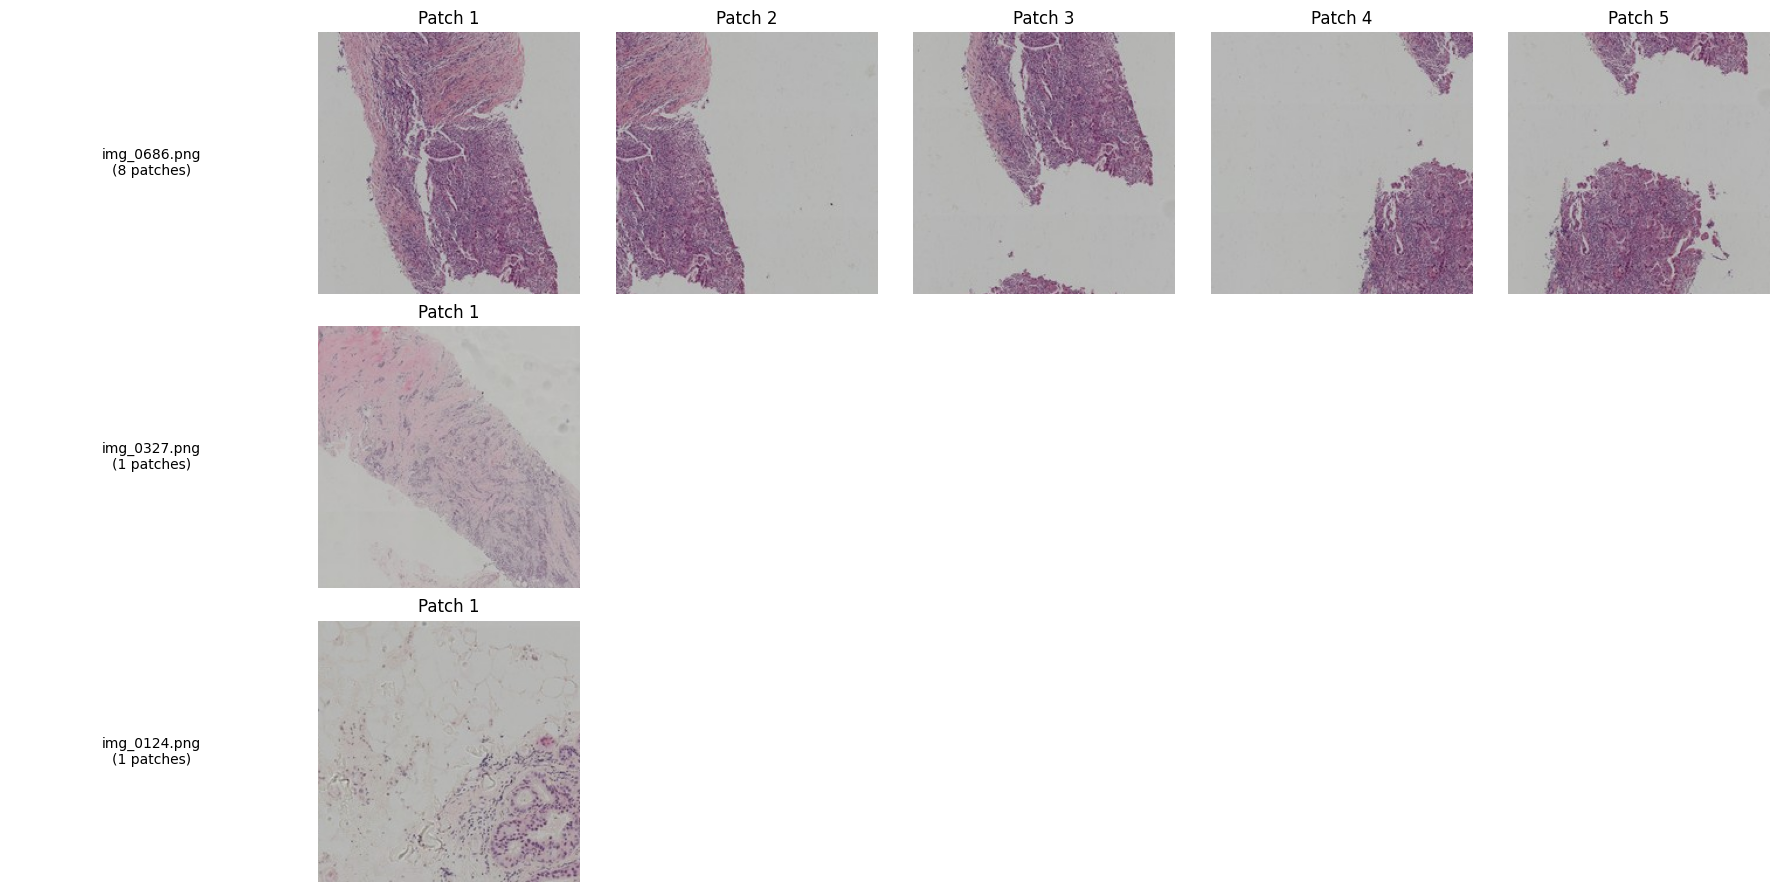

In [13]:
import matplotlib.pyplot as plt

def visualize_patches(X, img_indices, n_images=3, n_patches_per_image=4):
    """
    Visualize patches from different images.
    """
    unique_images = np.unique(img_indices)
    selected_images = np.random.choice(unique_images, min(n_images, len(unique_images)), replace=False)

    fig, axes = plt.subplots(n_images, n_patches_per_image + 1, figsize=(3*(n_patches_per_image+1), 3*n_images))
    if n_images == 1:
        axes = axes.reshape(1, -1)

    for i, img_id in enumerate(selected_images):
        # Get patches for this image
        mask = img_indices == img_id
        patches_for_img = X[mask]

        axes[i, 0].text(0.5, 0.5, f"{img_id}\n({len(patches_for_img)} patches)",
                       ha='center', va='center', fontsize=10)
        axes[i, 0].axis('off')

        # Show patches
        for j in range(min(n_patches_per_image, len(patches_for_img))):
            patch = patches_for_img[j]
            # Convert from (C, H, W) to (H, W, C)
            patch = np.transpose(patch, (1, 2, 0))
            axes[i, j+1].imshow(patch)
            axes[i, j+1].axis('off')
            axes[i, j+1].set_title(f"Patch {j+1}")

        # Clear remaining subplots
        for j in range(len(patches_for_img), n_patches_per_image):
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.show()

print("Sample patches from training data:")
visualize_patches(X_train, img_indices_train, n_images=3, n_patches_per_image=5)

## 📈 Statistics Summary

In [14]:
print("="*60)
print("FINAL STATISTICS")
print("="*60)

print(f"\n📁 Training Data:")
print(f"   Total patches: {X_train.shape[0]}")
print(f"   Unique images: {len(np.unique(img_indices_train))}")
print(f"   Avg patches/image: {X_train.shape[0] / len(np.unique(img_indices_train)):.2f}")
print(f"   Patch shape: {X_train.shape[1:]}")
print(f"   Label distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"      {name}: {count} patches ({count/len(y_train)*100:.1f}%)")

print(f"\n📁 Test Data:")
print(f"   Total patches: {X_test.shape[0]}")
print(f"   Unique images: {len(np.unique(img_indices_test))}")
print(f"   Avg patches/image: {X_test.shape[0] / len(np.unique(img_indices_test)):.2f}")
print(f"   Patch shape: {X_test.shape[1:]}")

print(f"\n💾 Saved files:")
print(f"   {train_output}")
print(f"   {test_output}")

print("\n" + "="*60)
print("✅ Preprocessing complete! You can now use these .npz files.")
print("="*60)

FINAL STATISTICS

📁 Training Data:
   Total patches: 3302
   Unique images: 581
   Avg patches/image: 5.68
   Patch shape: (3, 224, 224)
   Label distribution:
      HER2(+): 809 patches (24.5%)
      Luminal A: 878 patches (26.6%)
      Luminal B: 1250 patches (37.9%)
      Triple negative: 365 patches (11.1%)

📁 Test Data:
   Total patches: 2563
   Unique images: 477
   Avg patches/image: 5.37
   Patch shape: (3, 224, 224)

💾 Saved files:
   ./train_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz
   ./test_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz

✅ Preprocessing complete! You can now use these .npz files.
